# Connect Forest Management Model with Forest Carbon Budget Model (without calibration)

## Set up Modelling Environment

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import os
from util_opt import compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, cbm_report, plugin_c_curves, compare_ws3_cbm, compile_events, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm_both

In [2]:
def select_case_study(case_study):
    print(f"Selected scenario: {case_study}")
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='redchris',
    description='Case Study:'
)
display(case_study_dropdown)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')

Dropdown(description='Case Study:', options=('redchris', 'goldenbear', 'equitysilver', 'test'), value='redchri…

In [3]:
case_study = case_study_dropdown.value

In [4]:
#Start Calculating the Running Time
Start = time.time()

In [5]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'

In [6]:
# Define case study mappings
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

# Retrieve model details based on case study
model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


## Create and Run `ForestModel` instance

In [7]:
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

(<Figure size 2000x500 with 4 Axes>,
 array([<Axes: title={'center': 'Harvested area'}, xlabel='Period', ylabel='Area (ha)'>,
        <Axes: title={'center': 'Harvested volume'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Growing Stock'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Ecosystem C stock'}, xlabel='Period', ylabel='Stock (ton)'>],
       dtype=object))

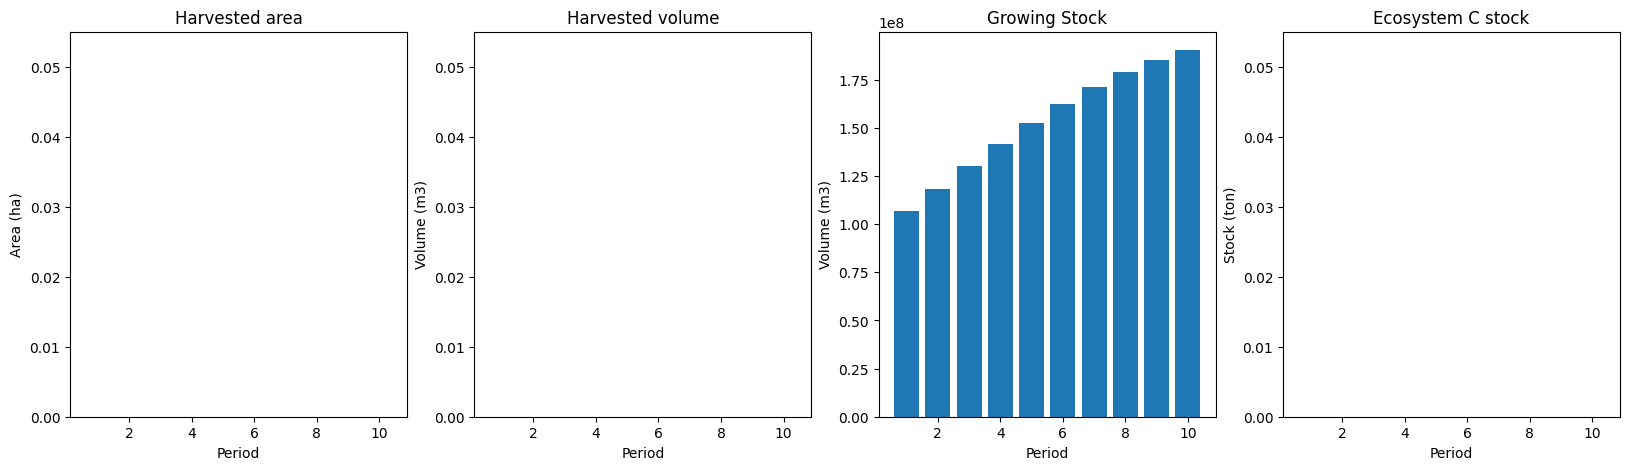

In [8]:
# Check the Forest Inventory of the Forest Model
df = compile_scenario_maxstock(fm)
plot_scenario_maxstock(df)

## Hard-link `ForestModel` to `libcbm`

Prepare CBM input files

In [9]:
# Define Disturance Types
disturbance_type_mapping = [{'user_dist_type': 'harvest', 'default_dist_type': 'Clearcut harvesting without salvage'},
                            {'user_dist_type': 'fire', 'default_dist_type': 'Wildfire'}]
for dtype_key in fm.dtypes:
    fm.dt(dtype_key).last_pass_disturbance = 'fire' if dtype_key[5] == dtype_key[4] else 'harvest'

Here are other two ways to generate sit tables. But they are only suitbale for small forest model since they take too much running time and memory

In [10]:
sit_config, sit_tables = fm.to_cbm_sit(softwood_volume_yname='swdvol', 
                                       hardwood_volume_yname='hwdvol', 
                                       admin_boundary='British Columbia', 
                                       eco_boundary='Montane Cordillera',
                        disturbance_type_mapping=disturbance_type_mapping)

In [11]:
from libcbm.input.sit import sit_reader
from libcbm.input.sit import sit_cbm_factory 
from libcbm.model.cbm.cbm_output import CBMOutput
from libcbm.storage.backends import BackendType
from libcbm.model.cbm import cbm_simulator
sit_data = sit_reader.parse(sit_classifiers=sit_tables['sit_classifiers'],
                            sit_disturbance_types=sit_tables['sit_disturbance_types'],
                            sit_age_classes=sit_tables['sit_age_classes'],
                            sit_inventory=sit_tables['sit_inventory'],
                            sit_yield=sit_tables['sit_yield'],
                            sit_events=sit_tables['sit_events'],
                            sit_transitions=sit_tables['sit_transitions'],
                            sit_eligibilities=None)
sit = sit_cbm_factory.initialize_sit(sit_data=sit_data, config=sit_config)
classifiers, inventory = sit_cbm_factory.initialize_inventory(sit)
cbm_output = CBMOutput(classifier_map=sit.classifier_value_names,
                       disturbance_type_map=sit.disturbance_name_map)
with sit_cbm_factory.initialize_cbm(sit) as cbm:
    # Create a function to apply rule based disturbance events and transition rules based on the SIT input
    rule_based_processor = sit_cbm_factory.create_sit_rule_based_processor(sit, cbm)
    # The following line of code spins up the CBM inventory and runs it through 200 timesteps.
    cbm_simulator.simulate(cbm,
                           n_steps=n_steps,
                           classifiers=classifiers,
                           inventory=inventory,
                           pre_dynamics_func=rule_based_processor.pre_dynamics_func,
                           reporting_func=cbm_output.append_simulation_result,
                           backend_type=BackendType.numpy)
pi = cbm_output.classifiers.to_pandas().merge(cbm_output.pools.to_pandas(), 
                                              left_on=["identifier", "timestep"], 
                                              right_on=["identifier", "timestep"])
biomass_pools = ['SoftwoodMerch','SoftwoodFoliage', 'SoftwoodOther', 'SoftwoodCoarseRoots','SoftwoodFineRoots',                        
                 'HardwoodMerch', 'HardwoodFoliage', 'HardwoodOther', 'HardwoodCoarseRoots', 'HardwoodFineRoots']
dom_pools = ['AboveGroundVeryFastSoil', 'BelowGroundVeryFastSoil', 'AboveGroundFastSoil', 'BelowGroundFastSoil',
             'MediumSoil', 'AboveGroundSlowSoil', 'BelowGroundSlowSoil', 'SoftwoodStemSnag', 'SoftwoodBranchSnag',
             'HardwoodStemSnag', 'HardwoodBranchSnag']

In [12]:
emissions_pools = ['CO2', 'CH4', 'CO', 'NO2']
ecosystem_pools = biomass_pools + dom_pools

In [13]:
# Define Time Steps
n_steps = fm.horizon * fm.period_length

# Run CBM and Generate CBM 0utputs
cbm_output = run_cbm_emissionstock(sit_config, sit_tables, n_steps)

Emissions from all biomass components only resulting from fire disturbance, while these from all DOM pools resulting from annual decay processes and fire disturbance.

In [14]:
# Define Carbon Fluxes
all_fluxes = [
    'DisturbanceCO2Production',
    'DisturbanceCH4Production',
    'DisturbanceCOProduction',
    'DisturbanceBioCO2Emission',
    'DisturbanceBioCH4Emission',
    'DisturbanceBioCOEmission',
    'DecayDOMCO2Emission',
    'DisturbanceSoftProduction',
    'DisturbanceHardProduction',
    'DisturbanceDOMProduction',
    'DeltaBiomass_AG',
    'DeltaBiomass_BG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput',
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir',
    'DisturbanceMerchToAir',
    'DisturbanceFolToAir',
    'DisturbanceOthToAir',
    'DisturbanceCoarseToAir',
    'DisturbanceFineToAir',
    'DisturbanceDOMCO2Emission',
    'DisturbanceDOMCH4Emission',
    'DisturbanceDOMCOEmission',
    'DisturbanceMerchLitterInput',
    'DisturbanceFolLitterInput',
    'DisturbanceOthLitterInput',
    'DisturbanceCoarseLitterInput',
    'DisturbanceFineLitterInput',
    'DisturbanceVFastAGToAir',
    'DisturbanceVFastBGToAir',
    'DisturbanceFastAGToAir',
    'DisturbanceFastBGToAir',
    'DisturbanceMediumToAir',
    'DisturbanceSlowAGToAir',
    'DisturbanceSlowBGToAir',
    'DisturbanceSWStemSnagToAir',
    'DisturbanceSWBranchSnagToAir',
    'DisturbanceHWStemSnagToAir',
    'DisturbanceHWBranchSnagToAir'
]

ecosystem_decay_emissions_pools = [
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir']
GrossGrowth_pools = [
    'DeltaBiomass_AG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'DeltaBiomass_BG',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput']

In [15]:
# Define Sum Carbon Pools and Sum Carbon Fluxes
pools = ecosystem_pools
fluxes = ecosystem_decay_emissions_pools
gross_growth = GrossGrowth_pools
sum_pools = ['ecosystem', 'biomass', 'DOM']

,Biomass,DOM,Ecosystem,All_Emissions,Gross_Growth,Stock_Change
Year,,,,,,
0,5.822073e+07,1.222542e+08,1.804750e+08,0.000000e+00,0.000000e+00,0.000000
1,5.871998e+07,1.221095e+08,1.808295e+08,2.698916e+06,3.053426e+06,-354510.028018
2,5.921411e+07,1.219807e+08,1.811948e+08,2.699385e+06,3.064685e+06,-365300.196877
3,5.970696e+07,1.218664e+08,1.815734e+08,2.700477e+06,3.079076e+06,-378598.301206
4,6.020047e+07,1.217660e+08,1.819664e+08,2.702128e+06,3.095212e+06,-393083.488615
...,...,...,...,...,...,...
96,8.888489e+07,1.328625e+08,2.217474e+08,3.118794e+06,3.422864e+06,-304069.939522
97,8.900069e+07,1.330478e+08,2.220485e+08,3.121645e+06,3.422719e+06,-301073.773681
98,8.910958e+07,1.332344e+08,2.223440e+08,3.124494e+06,3.420029e+06,-295534.434088


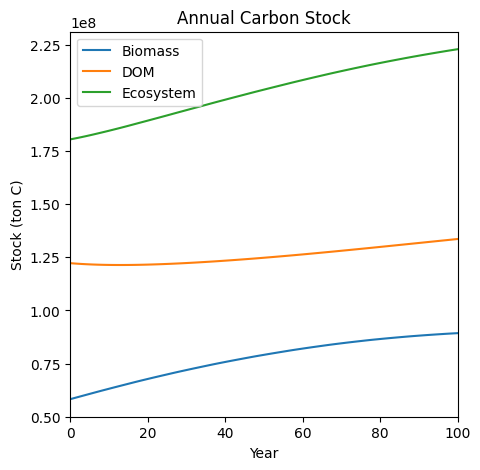

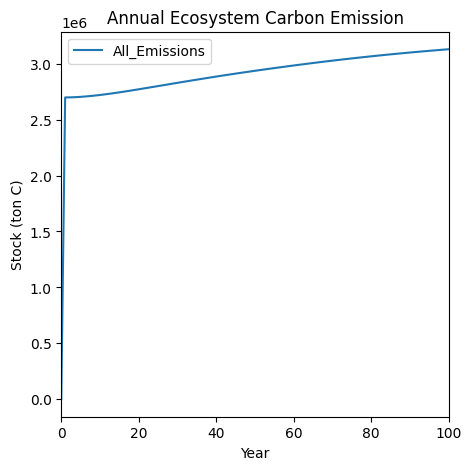

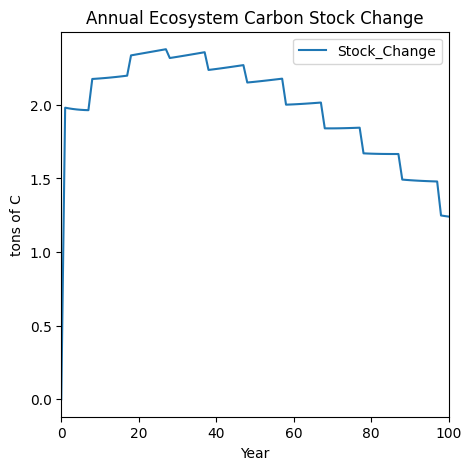

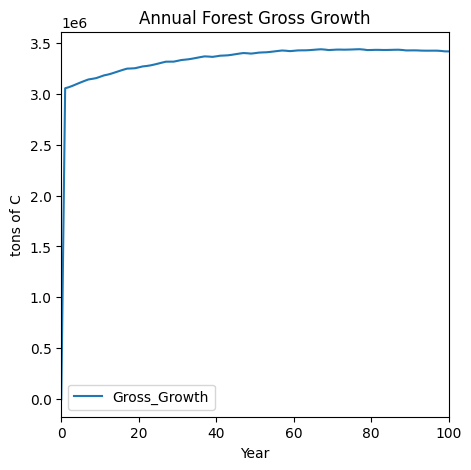

In [16]:
# Report Annual CBM Results
cbm_report(fm, cbm_output, biomass_pools, dom_pools, fluxes, gross_growth)

## Generate and Add Carbon Yield Curves

Carbon in product pools is considered a 100% immediate emission after harvesting activities.

Rebuild the inventory table. Set age to 0 and area to 1.0 ha.

The `sit_events` table should be empty.

In [17]:
sit_tables['sit_events']

,theme0,theme1,theme2,theme3,theme4,theme5,species,using_age_class,min_softwood_age,max_softwood_age,...,MinSWMerchStemSnagC,MaxSWMerchStemSnagC,MinHWMerchStemSnagC,MaxHWMerchStemSnagC,efficiency,sort_type,target_type,target,disturbance_type,disturbance_year


In [18]:
sit_tables['sit_inventory']

,theme0,theme1,theme2,theme3,theme4,theme5,species,using_age_class,age,area,delay,landclass,historic_disturbance,last_pass_disturbance
0,tsa03,0,1,100,1,1,softwood,FALSE,8,0.187482,0,0,fire,fire
1,tsa03,0,1,100,1,1,softwood,FALSE,15,0.475883,0,0,fire,fire
2,tsa03,0,1,100,1,1,softwood,FALSE,16,0.267715,0,0,fire,fire
3,tsa03,0,1,100,1,1,softwood,FALSE,27,0.952389,0,0,fire,fire
4,tsa03,0,1,100,1,1,softwood,FALSE,34,2.410174,0,0,fire,fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17018,tsa24,1,160,1211,160,160,hardwood,FALSE,98,2.858212,0,0,fire,fire
17019,tsa24,1,160,1211,160,160,hardwood,FALSE,143,2.225029,0,0,fire,fire
17020,tsa24,1,160,1211,160,160,hardwood,FALSE,188,1.399030,0,0,fire,fire
17021,tsa24,1,166,104,166,166,softwood,FALSE,213,0.262391,0,0,fire,fire


In [19]:
# Set Age and Area to 1 and 1.0
df = sit_tables['sit_inventory']
df['age'] = df['age'].apply(lambda x: 0)
df['area'] = df['area'].apply(lambda x: 1.0)
df = df.drop_duplicates(ignore_index=True)
df

,theme0,theme1,theme2,theme3,theme4,theme5,species,using_age_class,age,area,delay,landclass,historic_disturbance,last_pass_disturbance
0,tsa03,0,1,100,1,1,softwood,FALSE,0,1.0,0,0,fire,fire
1,tsa03,0,2,100,2,2,softwood,FALSE,0,1.0,0,0,fire,fire
2,tsa03,0,3,100,3,3,softwood,FALSE,0,1.0,0,0,fire,fire
3,tsa03,0,4,204,4,4,softwood,FALSE,0,1.0,0,0,fire,fire
4,tsa03,0,5,204,5,5,softwood,FALSE,0,1.0,0,0,fire,fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446,tsa24,1,158,1201,158,158,hardwood,FALSE,0,1.0,0,0,fire,fire
447,tsa24,1,159,1201,159,159,hardwood,FALSE,0,1.0,0,0,fire,fire
448,tsa24,1,160,1211,160,160,hardwood,FALSE,0,1.0,0,0,fire,fire
449,tsa24,1,166,104,166,166,softwood,FALSE,0,1.0,0,0,fire,fire


Use the following code if any of the developments have no harvesting circumstances.

In [20]:
# # Replace the Sit Inventory File in the Sit Table
sit_tables['sit_inventory'] = df

In [21]:
# Run CBM and Generate CBM 0utputs
cbm_output = run_cbm_emissionstock(sit_config, sit_tables, n_steps)

In [22]:
# Generate Carbon Pool and Flux Indicators
pi = cbm_output.classifiers.to_pandas().merge(cbm_output.pools.to_pandas(), 
                                              left_on=["identifier", "timestep"], 
                                              right_on=["identifier", "timestep"])
fi = cbm_output.classifiers.to_pandas().merge(cbm_output.flux.to_pandas(), 
                                              left_on=["identifier", "timestep"], 
                                              right_on=["identifier", "timestep"])

In [23]:
# Define Development Type Keys
pi['dtype_key'] = pi.apply(lambda r: '%s %s %s %s %s %s' % (r['theme0'], r['theme1'], r['theme2'], r['theme3'], r['theme4'], r['theme5']), axis=1)
fi['dtype_key'] = fi.apply(lambda r: '%s %s %s %s %s %s' % (r['theme0'], r['theme1'], r['theme2'], r['theme3'], r['theme4'], r['theme5']), axis=1)

In [24]:
# Generate Carbon Pool anf Flux Curves
c_curves_p = pi.groupby(['dtype_key', 'timestep'], as_index=True)[ecosystem_pools].sum()
c_curves_f = fi.groupby(['dtype_key', 'timestep'], as_index=True)[all_fluxes].sum()

In [25]:
# Generate sum carbon pool curves
c_curves_p['ecosystem'] = c_curves_p[ecosystem_pools].sum(axis=1)
c_curves_p['biomass'] = c_curves_p[biomass_pools].sum(axis=1)
c_curves_p['DOM'] = c_curves_p[dom_pools].sum(axis=1)

In [26]:
c_curves_f['total_emissions'] = 44/12 * c_curves_f[fluxes].sum(axis=1)
c_curves_f['gross_growth'] = 44/12 * c_curves_f[gross_growth].sum(axis=1)
c_curves_f['net_emissions'] = c_curves_f['total_emissions'] - c_curves_f['gross_growth']

In [27]:
# Curvs Calibration
# c_curves_p = c_curves_p.iloc[:,-3:].apply(lambda x: x*1.03) # Calibrate the carbon yield curvest for total ecosystem pools
# c_curves_f = c_curves_f.iloc[:,-2:].apply(lambda x: x*1.03) # Calibrate the carbon yield curvest for net carbon flux

In [28]:
# Use pickle.dump, to store the curves
file_directory = "./inputs/curves"
os.makedirs(file_directory, exist_ok=True)

file_data = {
    f"{case_study}_c_curves_p.pkl": c_curves_p,
    f"{case_study}_c_curves_f.pkl": c_curves_f
}

for filename, data in file_data.items():
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'wb') as file:
        pickle.dump(data, file)
    print(f"File saved at {file_path}")


File saved at ./inputs/curves/equitysilver_c_curves_p.pkl
File saved at ./inputs/curves/equitysilver_c_curves_f.pkl


In [29]:
# with open(f'{case_study}_c_curves_p_test.pkl', 'rb') as file:
#     c_curves_p = pickle.load(file)

In [30]:
# with open(f'{case_study}_c_curves_f_test.pkl', 'rb') as file:
#     c_curves_f = pickle.load(file)

In [31]:
# Plug carbon yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f, pools=sum_pools, fluxes=['net_emissions', 'total_emissions', 'gross_growth'])
# plugin_c_curves(fm, c_curves_p, pools=sum_pools) # This is only for c_curves_p

found match for mask ('?', '?', '?', '?', '1', '1')
found match for mask ('?', '?', '?', '?', '2', '2')
found match for mask ('?', '?', '?', '?', '3', '3')
found match for mask ('?', '?', '?', '?', '4', '4')
found match for mask ('?', '?', '?', '?', '5', '5')
found match for mask ('?', '?', '?', '?', '6', '6')
found match for mask ('?', '?', '?', '?', '7', '7')
found match for mask ('?', '?', '?', '?', '8', '8')
found match for mask ('?', '?', '?', '?', '9', '9')
found match for mask ('?', '?', '?', '?', '10', '10')
found match for mask ('?', '?', '?', '?', '11', '11')
found match for mask ('?', '?', '?', '?', '12', '12')
found match for mask ('?', '?', '?', '?', '13', '13')
found match for mask ('?', '?', '?', '?', '14', '14')
found match for mask ('?', '?', '?', '?', '15', '15')
found match for mask ('?', '?', '?', '?', '16', '16')
found match for mask ('?', '?', '?', '?', '17', '17')
found match for mask ('?', '?', '?', '?', '18', '18')
found match for mask ('?', '?', '?', '?', '19'

In [32]:
# Check if all carbon yield curves are plugged in well.
fm.yields

[(('?', '?', '?', '?', '?', '?'), '', []),
 (('?', '?', '?', '?', '12', '12'),
  'a',
  [('s1201', <ws3.core.Curve at 0x7f2316a7ea40>),
   ('ecosystem', <ws3.core.Curve at 0x7f22f8f8cd30>),
   ('biomass', <ws3.core.Curve at 0x7f22f8f8e470>),
   ('DOM', <ws3.core.Curve at 0x7f22f8f8c700>),
   ('net_emissions', <ws3.core.Curve at 0x7f22f8f8f190>),
   ('total_emissions', <ws3.core.Curve at 0x7f22f8f8c4c0>),
   ('gross_growth', <ws3.core.Curve at 0x7f22f8f8d240>),
   ('ecosystem', <ws3.core.Curve at 0x7f22f8f8cd30>),
   ('biomass', <ws3.core.Curve at 0x7f22f8f8e470>),
   ('DOM', <ws3.core.Curve at 0x7f22f8f8c700>),
   ('net_emissions', <ws3.core.Curve at 0x7f22f8f8f190>),
   ('total_emissions', <ws3.core.Curve at 0x7f22f8f8c4c0>),
   ('gross_growth', <ws3.core.Curve at 0x7f22f8f8d240>),
   ('ecosystem', <ws3.core.Curve at 0x7f22f8f8cd30>),
   ('biomass', <ws3.core.Curve at 0x7f22f8f8e470>),
   ('DOM', <ws3.core.Curve at 0x7f22f8f8c700>),
   ('net_emissions', <ws3.core.Curve at 0x7f22f8f8f1

(<Figure size 2000x500 with 4 Axes>,
 array([<Axes: title={'center': 'Harvested area'}, xlabel='Period', ylabel='Area (ha)'>,
        <Axes: title={'center': 'Harvested volume'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Growing Stock'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Ecosystem C stock'}, xlabel='Period', ylabel='Stock (ton)'>],
       dtype=object))

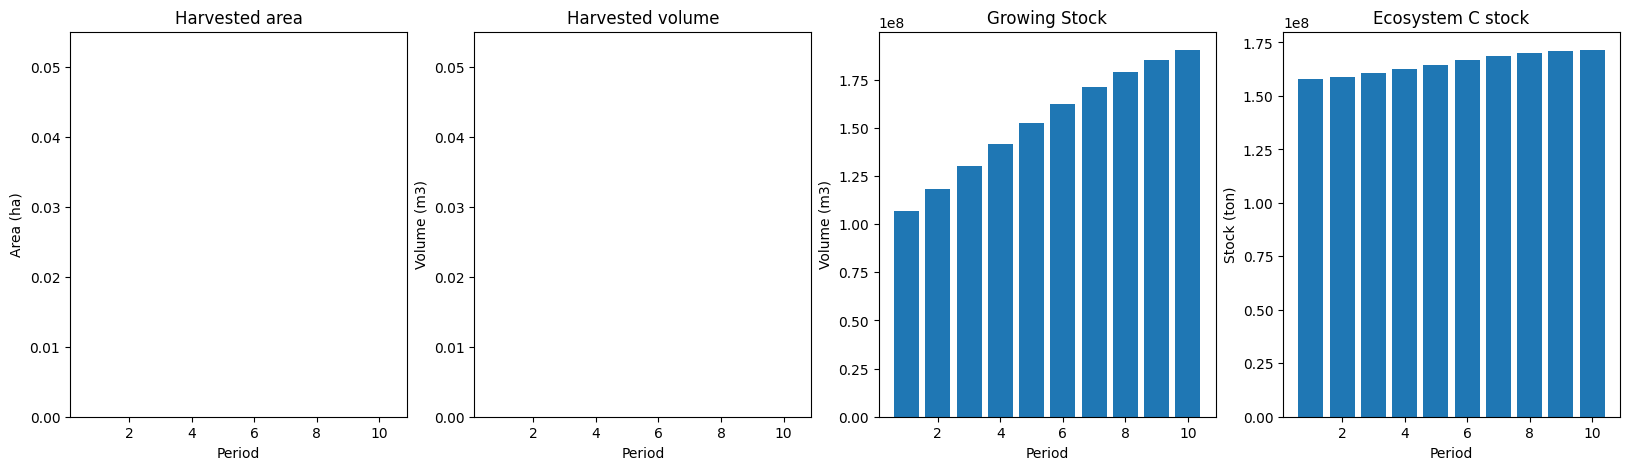

In [33]:
df = compile_scenario_maxstock(fm)
plot_scenario_maxstock(df)

In [34]:
# Run CBM and Generate CBM Ouputs
cbm_output = run_cbm_emissionstock(sit_config, sit_tables, n_steps)

,Biomass,DOM,Ecosystem,All_Emissions,Gross_Growth,Stock_Change,Net_Emissions
Year,,,,,,,
0,0.000000,87449.156928,87449.156928,0.000000,0.000000,0.000000,0.000000
1,74.646219,85663.749470,85738.395689,6605.630603,-332.839392,1710.761239,6272.791211
2,175.015069,84027.621068,84202.636138,6174.499675,-543.381322,1535.759551,5631.118354
3,296.265311,82515.237323,82811.502634,5828.735741,-727.912894,1391.133504,5100.822847
4,435.998209,81106.635565,81542.633773,5544.924990,-892.405834,1268.868861,4652.519156
...,...,...,...,...,...,...,...
96,31966.591581,58556.490773,90523.082355,5040.919489,-6518.214238,-402.898568,-1477.294748
97,32296.363683,58631.092151,90927.455834,5060.113828,-6542.816585,-404.373479,-1482.702757
98,32625.385106,58707.809512,91333.194618,5079.133366,-6566.842242,-405.738784,-1487.708876


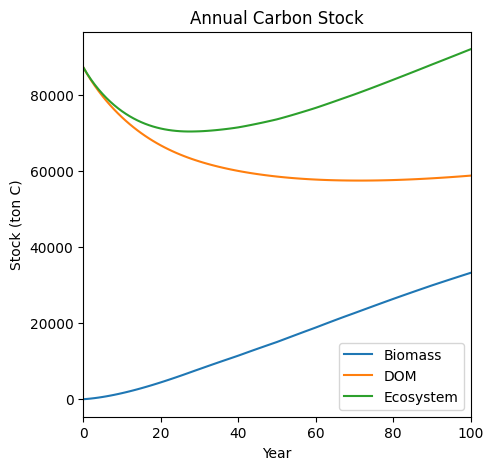

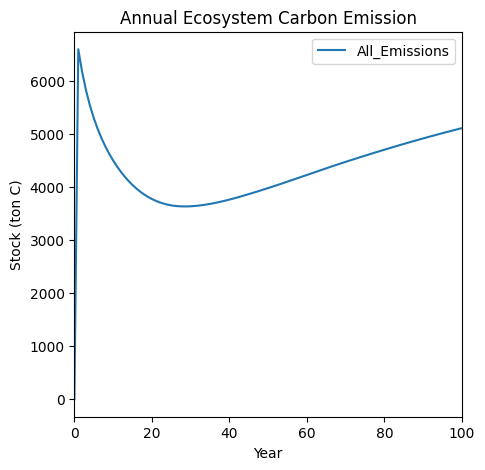

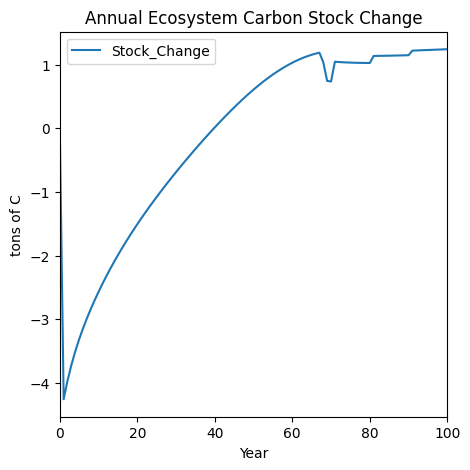

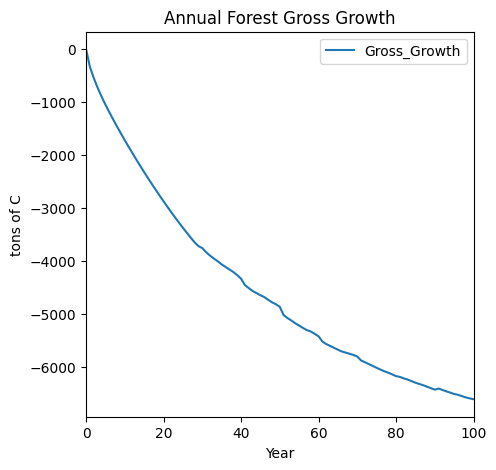

In [35]:
# Report Annual CBM Outputs
# cbm_report(fm, cbm_output, biomass_pools, dom_pools, fluxes, gross_growth)
cbm_report_both(fm, cbm_output, biomass_pools, dom_pools, fluxes, gross_growth)

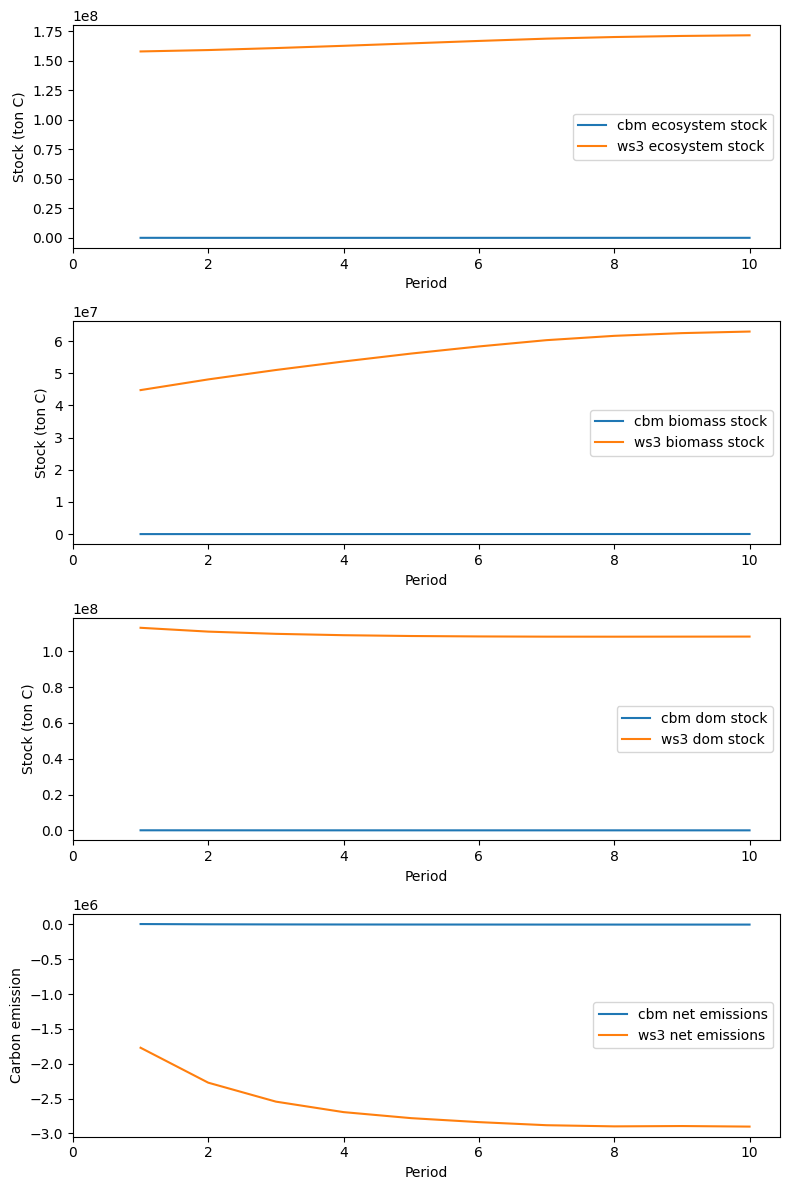

(   period  biomass_stock     dom_stock     eco_stock  \
 0       1      74.646219  85663.749470  85738.395689   
 1       2    1832.860756  73307.736982  75140.597738   
 2       3    4754.845415  66308.362274  71063.207690   
 3       4    8293.543580  62289.888258  70583.431838   
 4       5   11827.572292  59919.817093  71747.389386   
 5       6   15445.082097  58512.490426  73957.572523   
 6       7   19257.003047  57782.014062  77039.017109   
 7       8   23052.499422  57563.561625  80616.061047   
 8       9   26763.853330  57731.675377  84495.528707   
 9      10   30296.288314  58217.049547  88513.337861   
 
    ecosystem_decay_emissions  gross_growth  net_emissions  eco_stock_change  
 0                6605.630603   -332.839392    6272.791211          0.000000  
 1                4392.670120  -1840.869331    2551.800789     -10597.797951  
 2                3744.527132  -2972.368579     772.158553      -4077.390048  
 3                3646.672599  -3829.552195    -182.879

In [36]:
# Compare the carbon outputs from ws3 (table above) and libcbm (table below)
# compare_ws3_cbm(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, plots="individual")
compare_ws3_cbm_both(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, ecosystem_decay_emissions_pools, GrossGrowth_pools, plots="individual")

In [37]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 18.4 minutes to run this script.
